## **Task 1: Dataset Selection and Schema Report**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load the dataset
df = pd.read_csv("../data/raw/Churn_Modelling.csv")

# Display the first 5 rows
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
print("Dataset Shape", df.shape)

Dataset Shape (10000, 14)


In [4]:
# Display all column names
print("Column names:")
print(df.columns.tolist())

Column names:
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [5]:
# Display the data type of each column
print("Data types:")
print(df.dtypes)

Data types:
RowNumber            int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


In [6]:
# Count missing values in each column
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [7]:
# Count unique values in each column
print("Unique values per column:")
print(df.nunique())

Unique values per column:
RowNumber          10000
CustomerId         10000
Surname             2932
CreditScore          460
Geography              3
Gender                 2
Age                   70
Tenure                11
Balance             6382
NumOfProducts          4
HasCrCard              2
IsActiveMember         2
EstimatedSalary     9999
Exited                 2
dtype: int64


In [8]:
# Create a schema report
schema_report = pd.DataFrame({
    "Data Type": df.dtypes.astype(str),
    "Missing Values": df.isnull().sum(),
    "Unique Values": df.nunique()
})

schema_report

,Data Type,Missing Values,Unique Values
RowNumber,int64,0,10000
CustomerId,int64,0,10000
Surname,str,0,2932
CreditScore,int64,0,460
Geography,str,0,3
Gender,str,0,2
Age,int64,0,70
Tenure,int64,0,11
Balance,float64,0,6382
NumOfProducts,int64,0,4


**Dataset Selection**

Dataset: Churn Modelling Dataset

Why I chose this dataset:  
I chose the Churn Modelling dataset because it contains both numerical and categorical variables and has 10,000 records. This makes it suitable for data cleaning, feature engineering, NumPy computations, and exploratory data analysis.

Question explored:
What customer characteristics and account-related factors are associated with customer churn?

Source: 
Kaggle: https://www.kaggle.com/datasets/shrutimechlearn/churn-modelling

License: 
Not clearly specified

## **Task 2: Data Cleaning**

In [9]:
# Check for missing values
missing_values = df.isnull().sum()

print("Missing values per column:")
print(missing_values)
# No missing values were found, so no imputation or row removal was necessary.

Missing values per column:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [10]:
# Check the current data types
print(df.dtypes)

RowNumber            int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


In [11]:
# Remove columns that are identifiers and are not useful for customer churn analysis
df_clean = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

print("Shape before removing identifier columns:", df.shape)
print("Shape after removing identifier columns:", df_clean.shape)

Shape before removing identifier columns: (10000, 14)
Shape after removing identifier columns: (10000, 11)


In [12]:
# Check for duplicate rows
duplicate_count = df_clean.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [13]:
# Remove duplicate rows, if any
df_clean = df_clean.drop_duplicates()

print("Shape after removing duplicates:", df_clean.shape)

Shape after removing duplicates: (10000, 11)


In [14]:
# Verify the cleaned dataset
print("Cleaned dataset shape:", df_clean.shape)

print("\nMissing values:")
print(df_clean.isnull().sum())

print("\nDuplicate rows:")
print(df_clean.duplicated().sum())

print("\nData types:")
print(df_clean.dtypes)

Cleaned dataset shape: (10000, 11)

Missing values:
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicate rows:
0

Data types:
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


**Data Cleaning**

The dataset was checked for missing values, data type issues, and duplicate records. No missing values were found, so no imputation or removal of missing records was necessary.

The data types were reviewed and the numerical and categorical columns were already stored in appropriate formats. The `RowNumber`, `CustomerId`, and `Surname` columns were removed because they are identifiers and do not provide meaningful information for analyzing customer churn.

Duplicate records were also checked and removed if present. These cleaning steps produced a dataset focused on variables relevant to customer characteristics and churn.

## **Task 3: Feature Engineering with GroupBy and Merge**

In [15]:
print("Starting dataframe shape:", df_clean.shape)

Starting dataframe shape: (10000, 11)


In [16]:
# Calculate average balance and salary for each geographical location
geo_summary = (
    df_clean.groupby("Geography")
    .agg(
        AvgBalance=("Balance", "mean"),
        AvgSalary=("EstimatedSalary", "mean")
    )
    .reset_index()
)

geo_summary

,Geography,AvgBalance,AvgSalary
0,France,62092.636516,99899.180814
1,Germany,119730.116134,101113.435102
2,Spain,61818.147763,99440.572281


In [17]:
# Record shape before the merge
print("Shape before merge:", df_clean.shape)

# Merge geographical averages back into the main dataframe
df_features = df_clean.merge(
    geo_summary,
    on="Geography",
    how="left"
)

print("Shape after merge:", df_features.shape)

df_features.head()

Shape before merge: (10000, 11)
Shape after merge: (10000, 13)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AvgBalance,AvgSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,62092.636516,99899.180814
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,61818.147763,99440.572281
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,62092.636516,99899.180814
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,62092.636516,99899.180814
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,61818.147763,99440.572281


In [18]:
# Create a pivot table showing the average churn rate
# by geography and gender
churn_pivot = df_features.pivot_table(
    values="Exited",
    index="Geography",
    columns="Gender",
    aggfunc="mean"
)

print("Dataframe shape before pivot:", df_features.shape)
print("Pivot table shape:", churn_pivot.shape)

churn_pivot

Dataframe shape before pivot: (10000, 13)
Pivot table shape: (3, 2)


Gender,Female,Male
Geography,,
France,0.203450,0.127134
Germany,0.375524,0.278116
Spain,0.212121,0.131124


 **Feature Engineering with GroupBy and Merge**

A GroupBy aggregation was used to calculate the average account balance and average estimated salary for customers in each geographical location. These group-level statistics were merged back into the main dataframe, allowing each customer to be compared with the typical financial characteristics of customers from the same location.

A pivot table was also created to examine how customer churn rates vary across geographical locations and gender. Since the `Exited` column is binary, its mean represents the proportion of customers who churned within each group.

## **Task 4: NumPy-Based Computation**

In [19]:
# Convert the Balance column to a NumPy array
balance_array = df_features["Balance"].to_numpy()

# Calculate the mean and standard deviation
balance_mean = np.mean(balance_array)
balance_std = np.std(balance_array)

# Standardize Balance using a vectorized NumPy operation
balance_standardized = (balance_array - balance_mean) / balance_std

# Add the standardized values back to the dataframe
df_features["BalanceStandardized"] = balance_standardized

In [20]:
print("Mean:", np.mean(balance_standardized))
print("Standard Deviation:", np.std(balance_standardized))
print("Minimum:", np.min(balance_standardized))
print("Maximum:", np.max(balance_standardized))

Mean: -6.536993168992922e-17
Standard Deviation: 0.9999999999999999
Minimum: -1.2258476714090278
Maximum: 2.7953233217054723


**NumPy-Based Computation**

The `Balance` column was converted into a NumPy array and standardized using a vectorized z-score transformation. The calculation was performed using NumPy broadcasting without an explicit Python loop.

The standardized values have a mean close to zero and a standard deviation close to one. The resulting values were added back to the dataframe as the `BalanceStandardized` feature.

## Task 5: Exploratory Visualization

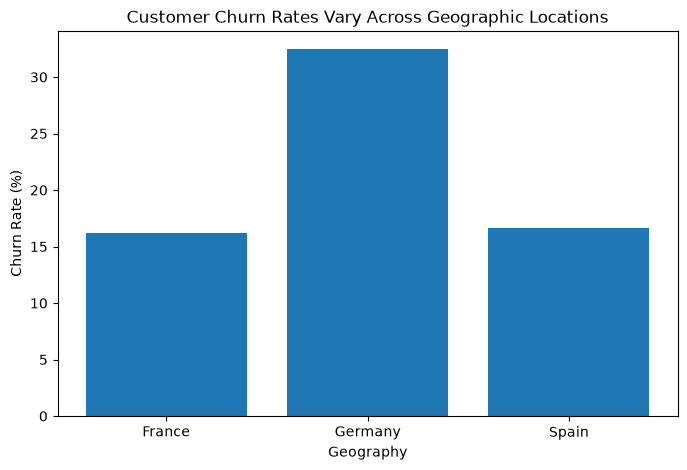

In [21]:
# Calculate churn rate by geography
churn_by_geography = df_features.groupby("Geography")["Exited"].mean() * 100

# Create the chart
plt.figure(figsize=(8, 5))
plt.bar(churn_by_geography.index, churn_by_geography.values)

plt.xlabel("Geography")
plt.ylabel("Churn Rate (%)")
plt.title("Customer Churn Rates Vary Across Geographic Locations")

# Save the chart
plt.savefig("../reports/a2_chart1.png", dpi=150, bbox_inches="tight")

plt.show()

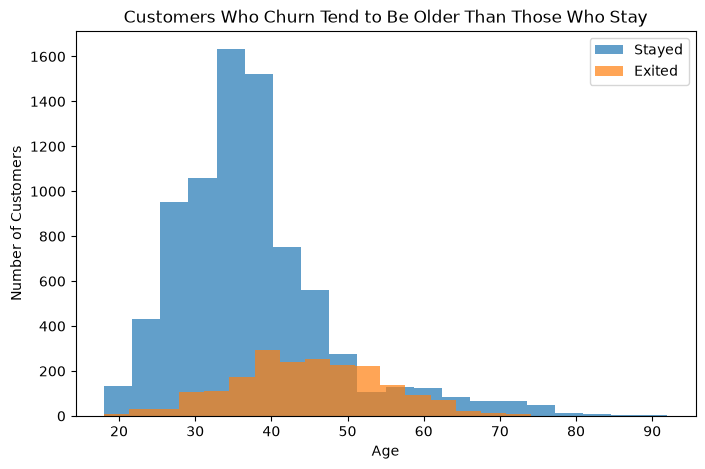

In [22]:
# Separate customers based on churn status
stayed = df_features[df_features["Exited"] == 0]
exited = df_features[df_features["Exited"] == 1]

# Create the chart
plt.figure(figsize=(8, 5))

plt.hist(stayed["Age"], bins=20, alpha=0.7, label="Stayed")
plt.hist(exited["Age"], bins=20, alpha=0.7, label="Exited")

plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.title("Customers Who Churn Tend to Be Older Than Those Who Stay")
plt.legend()

# Save the chart
plt.savefig("../reports/a2_chart2.png", dpi=150, bbox_inches="tight")

plt.show()

## **Task 6: Cleaned Dataset and Report**

In [23]:
# Save the cleaned and feature-engineered dataset
df_features.to_csv(
    "../data/processed/churn_cleaned_features.csv",
    index=False
)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.
